# **Assignment 1**
**Course:** Introduction to Data Security Practicum (ELTE)  
**Total Points:** 20  
**Time:** 45 min

---

1. **Part 1 (7 pts):** Evasion Attacks – Bypass a spam filter via word substitution
2. **Part 2 (5 pts):** Data Poisoning – Corrupt training data to degrade a model
3. **Part 3 (4 pts):** Model Trojans – Inject hidden functionality into model weights
4. **Part 4 (4 pts):** Integration & Defense – Design a defense strategy

Each part includes scaffolded code with `TODO` comments. Follow the instructions and fill in the blanks.

## **PART 1: Evasion Attacks (7 pts)**

Implement a **white-box greedy substitution** attack against a TF-IDF + Logistic Regression spam classifier. Replace "spammy" words with "hammy" words until the filter is fooled.

- Extract model weights and identify important features
- Implement iterative gradient-free attacks
- Measure attack success (ASR, L0)

In [8]:
from google.colab import files

# This opens a file picker - hold Ctrl (Windows) or Cmd (Mac)
# to select multiple files at once
uploaded = files.upload()
# Select all 3 files together:
# - spam_classifier.joblib
# - tfidf_vectorizer.joblib
# - spam_dataset_in_.csv

Saving spam_dataset.csv to spam_dataset.csv
Saving tfidf_vectorizer.joblib to tfidf_vectorizer (2).joblib
Saving spam_classifier.joblib to spam_classifier (4).joblib


In [11]:
import os

# Step 1: See exactly what files were saved
print("Files in current directory:")
for f in os.listdir():
    print(f" - {f}")

Files in current directory:
 - .config
 - spam_dataset(in) (1).csv
 - Assignment_1.ipynb
 - spam_classifier (4).joblib
 - Assignment_1 (1).ipynb
 - tfidf_vectorizer (1).joblib
 - spam_classifier (1).joblib
 - tfidf_vectorizer.joblib
 - spam_dataset(in).csv
 - spam_dataset.csv
 - spam_classifier (3).joblib
 - tfidf_vectorizer (2).joblib
 - spam_classifier.joblib
 - spam_classifier (2).joblib
 - sample_data


In [12]:
import os

# Rename to the correct expected filenames
os.rename('tfidf_vectorizer (2).joblib', 'tfidf_vectorizer.joblib')
os.rename('spam_classifier (4).joblib', 'spam_classifier.joblib')
os.rename('spam_dataset.csv',           'spam_dataset_in_.csv')

print("✅ All files renamed successfully!")

✅ All files renamed successfully!


In [13]:
for f in ['spam_classifier.joblib', 'tfidf_vectorizer.joblib', 'spam_dataset_in_.csv']:
    if os.path.exists(f):
        print(f"✅ {f} - found")
    else:
        print(f"❌ {f} - NOT found")

✅ spam_classifier.joblib - found
✅ tfidf_vectorizer.joblib - found
✅ spam_dataset_in_.csv - found


In [14]:
import pandas as pd
import numpy as np
import joblib
import re

# Load the provided pre-trained model and vectorizer
model = joblib.load('spam_classifier.joblib')
vectorizer = joblib.load('tfidf_vectorizer.joblib')

# --- HELPER FUNCTIONS PROVIDED ---
def get_prediction(text):
    """Returns (predicted_class, probabilities). Class 1 = Spam, Class 0 = Ham."""
    features = vectorizer.transform([text])
    prediction = model.predict(features)[0]
    probs = model.predict_proba(features)[0]
    return prediction, probs

def get_word_score(word):
    """Returns the model weight for a word. Positive = Spammy, Negative = Hammy."""
    word = word.lower()
    vocab = vectorizer.vocabulary_
    weights = model.coef_[0]
    if word in vocab:
        return weights[vocab[word]]
    return 0.0

def get_all_vocab_words():
    """Returns all words in the model vocabulary."""
    return vectorizer.get_feature_names_out()

### Task 1.1: Build Ham Library (2 pts)
Create a list of the top 20 words with the **most negative weights** (strongest indicators of "Ham").

In [ ]:
# TODO: Find the top 20 words with the most negative weights.
# Hint: Use get_all_vocab_words() and model.coef_[0], then sort by ascending weight.

ham_library = []  # FILL THIS IN

print(f"Ham library (first 5): {ham_library[:5]}")

In [16]:
# TODO: Find the top 20 words with the most negative weights.
# Hint: Use get_all_vocab_words() and model.coef_[0], then sort by ascending weight.

# Step 1: Get all vocabulary words and their corresponding model weights
vocab_words = get_all_vocab_words()       # all 5000 words in the TF-IDF vocabulary
weights     = model.coef_[0]             # model weight for each word

# Step 2: Pair each word with its weight, then sort ascending (most negative first)
word_weight_pairs = sorted(zip(vocab_words, weights), key=lambda x: x[1])

# Step 3: Extract just the top 20 most negative words (strongest Ham indicators)
ham_library = [word for word, weight in word_weight_pairs[:20]]

# Verify
print(f"Ham library (first 5): {ham_library[:5]}")
print(f"\nFull Ham library ({len(ham_library)} words):")
print("-" * 40)
for i, (word, weight) in enumerate(word_weight_pairs[:20]):
    print(f"  {i+1:2}. {word:<20} weight: {weight:.4f}")


Ham library (first 5): ['ok', 'gt', 'lt', 'll', 'da']

Full Ham library (20 words):
----------------------------------------
   1. ok                   weight: -1.8075
   2. gt                   weight: -1.6912
   3. lt                   weight: -1.6773
   4. ll                   weight: -1.6637
   5. da                   weight: -1.4181
   6. come                 weight: -1.3884
   7. home                 weight: -1.3454
   8. got                  weight: -1.3289
   9. lor                  weight: -1.2181
  10. sorry                weight: -1.1816
  11. hey                  weight: -1.1410
  12. going                weight: -1.1174
  13. later                weight: -1.1157
  14. good                 weight: -1.0807
  15. way                  weight: -1.0178
  16. sir                  weight: -0.9605
  17. did                  weight: -0.9333
  18. yeah                 weight: -0.9196
  19. happy                weight: -0.9173
  20. right                weight: -0.9068


### Task 1.2: Find Most Spammy Word (1 pts)
Write a function that identifies the word in a given text with the **highest positive weight**.

In [ ]:
def find_most_spammy_word(text):
    # TODO: Implement this function.
    # 1. Tokenize the text using: re.findall(r'\\b\\w+\\b', text)
    # 2. For each word, get its score using get_word_score(word)
    # 3. Return the word with the HIGHEST score (most spammy)
    # Hint: If no words are found or all have score 0, return None

    best_word = None
    # YOUR CODE HERE

    return best_word

# Test it
test_email = "URGENT! YOU HAVE WON A FREE PRIZE"
result = find_most_spammy_word(test_email)
print(f"Most spammy word in test email: '{result}'")

In [17]:
def find_most_spammy_word(text):
    # Step 1: Tokenize the text into individual words
    words = re.findall(r'\b\w+\b', text)

    # Step 2: Handle empty text case
    if not words:
        return None

    # Step 3: Get the score for each word and track the best
    best_word  = None
    best_score = 0  # Only care about positive scores (spammy words)

    for word in words:
        score = get_word_score(word)
        if score > best_score:
            best_score = score
            best_word  = word

    return best_word

# Test it
test_email = "URGENT! YOU HAVE WON A FREE PRIZE"
result = find_most_spammy_word(test_email)
print(f"Most spammy word in test email: '{result}'")

# Extra verification - show scores of all words in the test email
print("\nAll word scores in test email:")
print("-" * 35)
for word in re.findall(r'\b\w+\b', test_email):
    score = get_word_score(word)
    print(f"  {word:<15} score: {score:.4f}")


Most spammy word in test email: 'FREE'

All word scores in test email:
-----------------------------------
  URGENT          score: 2.4421
  YOU             score: 0.0000
  HAVE            score: 0.0000
  WON             score: 2.3738
  A               score: 0.0000
  FREE            score: 2.9667
  PRIZE           score: 2.5274


### Task 1.3: Iterative Evasion Attack (2 pts)
Implement the attack loop: repeatedly replace the most spammy word with a ham word until the model flips to Ham.

In [18]:
target_spam_email = "URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net"

In [ ]:
def guided_evasion_attack(email, ham_library):
    """Iteratively replace spammy words with ham words until model predicts Ham.

    Args:
        email (str): Original spam email
        ham_library (list): List of ham words to substitute

    Returns:
        (adversarial_email, num_changes): Modified email and substitution count
    """
    current_email = email
    changes = 0

    # TODO: Implement the loop. Requirements:
    # 1. Loop while prediction is Spam (pred == 1)
    # 2. Find the most spammy word using find_most_spammy_word()
    # 3. If no word found, break
    # 4. Pick a replacement from ham_library[changes % len(ham_library)]
    # 5. Replace the word using: re.sub(r'\\b' + re.escape(word) + r'\\b', replacement, current_email, count=1, flags=re.IGNORECASE)
    # 6. Increment changes
    # 7. Add safety cap: break if changes >= 20

    # YOUR CODE HERE

    return current_email, changes

# Run the attack
adv_email, n_changes = guided_evasion_attack(target_spam_email, ham_library)
pred, probs = get_prediction(adv_email)

print(f"Original prediction: Spam (1.0)")
print(f"Attack result: {'SUCCESS' if pred == 0 else 'FAILED'}")
print(f"Changes made: {n_changes}")
print(f"Final Ham probability: {probs[0]*100:.2f}%")
print(f"\nAdversarial email: {adv_email}")

In [19]:
def guided_evasion_attack(email, ham_library):
    """Iteratively replace spammy words with ham words until model predicts Ham.

    Args:
        email (str): Original spam email
        ham_library (list): List of ham words to substitute

    Returns:
        (adversarial_email, num_changes): Modified email and substitution count
    """
    current_email = email
    changes = 0

    # Loop while the model still predicts Spam (pred == 1)
    while True:
        # Step 1: Check current prediction
        pred, probs = get_prediction(current_email)

        # Step 2: If model now predicts Ham, attack succeeded - stop
        if pred == 0:
            break

        # Step 3: Safety cap - stop if too many changes made
        if changes >= 20:
            break

        # Step 4: Find the most spammy word in the current email
        spammy_word = find_most_spammy_word(current_email)

        # Step 5: If no spammy word found, nothing left to replace - stop
        if spammy_word is None:
            break

        # Step 6: Pick a replacement ham word (cycle through ham_library)
        replacement = ham_library[changes % len(ham_library)]

        # Step 7: Replace the spammy word with the ham word (case-insensitive)
        current_email = re.sub(
            r'\b' + re.escape(spammy_word) + r'\b',
            replacement,
            current_email,
            count=1,
            flags=re.IGNORECASE
        )

        # Step 8: Increment change counter
        changes += 1

        # Optional: Print each substitution step for transparency
        print(f"  Step {changes}: '{spammy_word}' → '{replacement}' | "
              f"Spam prob: {probs[1]*100:.1f}%")

    return current_email, changes


# Run the attack
target_spam_email = "URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net"

adv_email, n_changes = guided_evasion_attack(target_spam_email, ham_library)
pred, probs = get_prediction(adv_email)

print(f"\n{'='*50}")
print(f"Original email:    {target_spam_email}")
print(f"Adversarial email: {adv_email}")
print(f"{'='*50}")
print(f"Original prediction: Spam (1)")
print(f"Attack result:       {'✅ SUCCESS' if pred == 0 else '❌ FAILED'}")
print(f"Changes made:        {n_changes}")
print(f"Final Ham prob:      {probs[0]*100:.2f}%")
print(f"Final Spam prob:     {probs[1]*100:.2f}%")


  Step 1: 'Txt' → 'ok' | Spam prob: 94.7%
  Step 2: 'CLAIM' → 'gt' | Spam prob: 85.9%
  Step 3: 'www' → 'lt' | Spam prob: 70.0%

Original email:    URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net
Adversarial email: URGENT! You have won a 1 week FREE membership in our £100,000 Prize Jackpot! ok the word: gt to No: 81010 T&C lt.dbuk.net
Original prediction: Spam (1)
Attack result:       ✅ SUCCESS
Changes made:        3
Final Ham prob:      52.43%
Final Spam prob:     47.57%


### Task 1.4: Evaluation Metrics (2 pts)
Compute **Attack Success Rate (ASR)** and **Average Perturbation (L0)** over 50 spam samples.

In [ ]:
df = pd.read_csv('spam_dataset.csv')
spam_samples = df[df['label'] == 1].head(50)['text'].tolist()

success_count = 0
l0_successful = []

# TODO: Loop through spam_samples, run attack on each, and collect metrics.
# - Count successful attacks (pred == 0)
# - Record number of changes for successful attacks in l0_successful list

# YOUR CODE HERE

asr = (success_count / len(spam_samples)) * 100
avg_l0 = np.mean(l0_successful) if l0_successful else 0.0

print(f"Attack Success Rate (ASR): {asr:.1f}%")
print(f"Average Perturbation (L0): {avg_l0:.2f} word substitutions")
print(f"Successful attacks: {success_count}/{len(spam_samples)}")

In [21]:
# More robust CSV loading
df = pd.read_csv('spam_dataset_in_.csv',
                 encoding='latin-1',
                 on_bad_lines='skip',    # skip malformed lines
                 sep=',',
                 engine='python')

# Preview what we loaded
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

Shape: (4197, 2)
Columns: ['label', 'text;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;']
  label           text;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;
0     0  Ok lar... Joking wif u oni...;;;;;;;;;;;;;;;;;...
1     1  Free entry in 2 a wkly comp to win FA Cup fina...
2     0  U dun say so early hor... U c already then say...


In [22]:
# Fix the messy column name
df.columns = ['label', 'text']

# Clean the text column - remove the semicolons at the end
df['text'] = df['text'].str.replace(';', '', regex=False).str.strip()

# Clean up labels
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df.dropna(subset=['label', 'text'])
df['label'] = df['label'].astype(int)

# Verify
print(f"Clean dataset shape: {df.shape}")
print(f"\nLabel counts:\n{df['label'].value_counts()}")
print(f"\nSample rows:")
print(df.head(3))

Clean dataset shape: (4196, 2)

Label counts:
label
0    3697
1     499
Name: count, dtype: int64

Sample rows:
   label                                               text
0      0                      Ok lar... Joking wif u oni...
1      1  Free entry in 2 a wkly comp to win FA Cup fina...
2      0  U dun say so early hor... U c already then say...


In [23]:
# Get 50 spam samples
spam_samples = df[df['label'] == 1].head(50)['text'].tolist()
print(f"\nLoaded {len(spam_samples)} spam samples")
print(f"Sample spam email: {spam_samples[0][:80]}...")


Loaded 50 spam samples
Sample spam email: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8...


In [24]:
success_count = 0
l0_successful = []

for i, email in enumerate(spam_samples):
    adv_email, n_changes = guided_evasion_attack(email, ham_library)
    pred, probs = get_prediction(adv_email)

    if pred == 0:
        success_count += 1
        l0_successful.append(n_changes)

    if (i + 1) % 10 == 0:
        print(f"  Processed {i+1}/50 emails... "
              f"Success so far: {success_count}/{i+1}")

# Final metrics
asr    = (success_count / len(spam_samples)) * 100
avg_l0 = np.mean(l0_successful) if l0_successful else 0.0

print(f"\n{'='*45}")
print(f"  Attack Success Rate (ASR): {asr:.1f}%")
print(f"  Average Perturbation (L0): {avg_l0:.2f} word substitutions")
print(f"  Successful attacks:        {success_count}/{len(spam_samples)}")
print(f"  Failed attacks:            {len(spam_samples)-success_count}/{len(spam_samples)}")
print(f"{'='*45}")

  Step 1: 'txt' → 'ok' | Spam prob: 70.1%
  Step 2: 'Free' → 'gt' | Spam prob: 52.2%
  Step 1: 'claim' → 'ok' | Spam prob: 80.0%
  Step 2: 'Claim' → 'gt' | Spam prob: 65.4%
  Step 1: 'mobile' → 'ok' | Spam prob: 76.8%
  Step 2: 'Mobile' → 'gt' | Spam prob: 60.5%
  Step 1: 'UK' → 'ok' | Spam prob: 66.1%
  Step 1: 'mobile' → 'ok' | Spam prob: 89.8%
  Step 2: 'reply' → 'gt' | Spam prob: 75.4%
  Step 3: 'free' → 'lt' | Spam prob: 53.2%
  Step 1: 'service' → 'ok' | Spam prob: 86.0%
  Step 2: 'prize' → 'gt' | Spam prob: 70.3%
  Step 3: 'WON' → 'lt' | Spam prob: 51.6%
  Step 1: 'Claim' → 'ok' | Spam prob: 82.5%
  Step 2: 'prize' → 'gt' | Spam prob: 65.6%
  Step 1: 'claim' → 'ok' | Spam prob: 86.8%
  Step 2: '18' → 'gt' | Spam prob: 69.4%
  Step 3: 'min' → 'lt' | Spam prob: 50.5%
  Step 1: 'claim' → 'ok' | Spam prob: 71.0%
  Step 2: 'Code' → 'gt' | Spam prob: 50.9%
  Processed 10/50 emails... Success so far: 10/10
  Step 1: 'claim' → 'ok' | Spam prob: 70.3%
  Step 1: 'Txt' → 'ok' | Spam prob: 

## **PART 2: Data Poisoning (5 pts)**

Implement **label-flipping poisoning**: corrupt training labels to degrade model accuracy on a specific class.

- Understand integrity attacks on training data
- Measure poison effectiveness vs. budget
- Analyze model behavior under poisoning

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# Set seeds
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True
)

# Use smaller subset for faster training
train_subset = Subset(train_dataset, np.random.choice(len(train_dataset), 5000, replace=False))
test_subset = Subset(test_dataset, np.random.choice(len(test_dataset), 1000, replace=False))

print(f"MNIST loaded. Train: {len(train_subset)}, Test: {len(test_subset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]

MNIST loaded. Train: 5000, Test: 1000


### Task 2.1: Create Poisoned Dataset (1 pts)
Implement label-flipping: randomly flip a fraction of labels in the training set.

In [26]:
def create_label_flip_poison(dataset, flip_fraction=0.2):
    """Flip labels of a random fraction of training samples.

    Args:
        dataset: Original dataset (list of tuples (image, label))
        flip_fraction: Fraction of samples to flip (0.0-1.0)

    Returns:
        poisoned_data: List of (image, new_label) tuples
        poison_indices: Indices of poisoned samples
    """
    # Copy original dataset into a mutable list
    poisoned_data = [(x, y) for x, y in dataset]

    # Step 1: Calculate number of samples to poison
    n_poison = int(len(poisoned_data) * flip_fraction)

    # Step 2: Randomly select n_poison unique indices
    poison_indices = np.random.choice(len(poisoned_data), n_poison, replace=False)

    # Step 3: Flip each selected label to a random DIFFERENT label (0-9)
    for idx in poison_indices:
        x, y = poisoned_data[idx]
        # All possible labels except the original one
        other_labels = [l for l in range(10) if l != y]
        new_label    = np.random.choice(other_labels)
        poisoned_data[idx] = (x, new_label)

    return poisoned_data, poison_indices


# Create poisoned dataset
poisoned_train, poison_idx = create_label_flip_poison(train_subset, flip_fraction=0.2)
print(f"Created poisoned dataset with {len(poison_idx)} flipped labels "
      f"({int(0.2*100)}% of {len(train_subset)})")

# Verify the poisoning
print(f"\nVerification:")
print(f"  Total samples:    {len(poisoned_train)}")
print(f"  Poisoned samples: {len(poison_idx)}")
print(f"  Clean samples:    {len(poisoned_train) - len(poison_idx)}")

# Show a few examples of flipped labels
print(f"\nSample flipped labels (first 5):")
for idx in poison_idx[:5]:
    _, original_label = train_subset[idx]
    _, new_label      = poisoned_train[idx]
    print(f"  Index {idx}: label {original_label} → {new_label}")


Created poisoned dataset with 1000 flipped labels (20% of 5000)

Verification:
  Total samples:    5000
  Poisoned samples: 1000
  Clean samples:    4000

Sample flipped labels (first 5):
  Index 3080: label 8 → 5
  Index 269: label 8 → 3
  Index 2730: label 7 → 3
  Index 2547: label 8 → 3
  Index 1523: label 2 → 3


### Task 2.2: Train on Poisoned Data (2 pts)
Train a simple MLP on clean vs. poisoned data and compare accuracy.

In [27]:
class SimpleMLP(nn.Module):
    """Simple MLP for MNIST."""
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train_model(data, epochs=5, batch_size=32, seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    generator = torch.Generator()
    generator.manual_seed(seed)
    loader = DataLoader(data, batch_size=batch_size, shuffle=True, generator=generator)

    model = SimpleMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    return model

def evaluate_model(model, data):
    """Evaluate model accuracy on dataset."""
    loader = DataLoader(data, batch_size=32, shuffle=False)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

In [28]:
class SimpleMLP(nn.Module):
    """Simple MLP for MNIST."""
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc1     = nn.Linear(28*28, 128)
        self.fc2     = nn.Linear(128, 10)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train_model(data, epochs=5, batch_size=32, seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    generator = torch.Generator()
    generator.manual_seed(seed)
    loader = DataLoader(data, batch_size=batch_size, shuffle=True, generator=generator)

    model     = SimpleMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    return model

def evaluate_model(model, data):
    """Evaluate model accuracy on dataset."""
    loader  = DataLoader(data, batch_size=32, shuffle=False)
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predicted   = torch.max(outputs.data, 1)
            total          += labels.size(0)
            correct        += (predicted == labels).sum().item()
    return correct / total

# TODO: Train two models
print("Training CLEAN model...")
clean_model    = train_model(train_subset)       # ← train on clean data

print("\nTraining POISONED model...")
poisoned_model = train_model(poisoned_train)     # ← train on poisoned data

# Evaluate both on the clean test set
clean_acc    = evaluate_model(clean_model,    test_subset)   # ← evaluate clean
poisoned_acc = evaluate_model(poisoned_model, test_subset)   # ← evaluate poisoned

# Print comparison
print(f"\n{'='*40}")
print(f"Clean model accuracy:    {clean_acc*100:.2f}%")
print(f"Poisoned model accuracy: {poisoned_acc*100:.2f}%")
print(f"Accuracy drop:           {(clean_acc - poisoned_acc)*100:.2f}%")
print(f"{'='*40}")

Training CLEAN model...

Training POISONED model...

Clean model accuracy:    90.20%
Poisoned model accuracy: 90.30%
Accuracy drop:           -0.10%


### Task 2.3: Targeted Poisoning (2 pts)
Flip only samples of class 3 to class 8 and measure the impact on 3→8 misclassification rate.

In [29]:
def create_targeted_poison(dataset, source_class=3, target_class=8, flip_fraction=0.5):
    """Flip only source_class samples to target_class."""

    # Copy original dataset
    poisoned_data = [(x, y) for x, y in dataset]

    # Step 1: Find all indices where label == source_class (3)
    source_indices = [i for i, (x, y) in enumerate(poisoned_data) if y == source_class]

    # Step 2: Randomly select flip_fraction of those indices
    n_poison       = int(len(source_indices) * flip_fraction)
    poison_indices = list(np.random.choice(source_indices, n_poison, replace=False))

    # Step 3: Change those samples' labels to target_class (8)
    for idx in poison_indices:
        x, _ = poisoned_data[idx]
        poisoned_data[idx] = (x, target_class)

    print(f"Found {len(source_indices)} samples of class {source_class}")
    print(f"Poisoned {n_poison} samples: class {source_class} → class {target_class}")

    return poisoned_data, poison_indices


# Create targeted poison
poisoned_train_targeted, poison_idx_targeted = create_targeted_poison(
    train_subset, source_class=3, target_class=8, flip_fraction=0.5
)

# Train model on targeted poisoned data
print("\nTraining TARGETED POISONED model...")
targeted_model = train_model(poisoned_train_targeted, epochs=5)

# Measure 3→8 misclassification rate on test set
loader        = DataLoader(test_subset, batch_size=32)
targeted_model.eval()
class_3_to_8  = 0
total_class_3 = 0

with torch.no_grad():
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        mask = labels == 3
        if mask.sum() > 0:
            outputs      = targeted_model(images[mask])
            _, predicted = torch.max(outputs.data, 1)
            class_3_to_8  += (predicted == 8).sum().item()
            total_class_3 += mask.sum().item()

misclassification_rate = class_3_to_8 / total_class_3 if total_class_3 > 0 else 0

# Also measure clean model's 3→8 rate for comparison
clean_model.eval()
clean_3_to_8  = 0
clean_total_3 = 0

with torch.no_grad():
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        mask = labels == 3
        if mask.sum() > 0:
            outputs      = clean_model(images[mask])
            _, predicted = torch.max(outputs.data, 1)
            clean_3_to_8  += (predicted == 8).sum().item()
            clean_total_3 += mask.sum().item()

clean_misclf_rate = clean_3_to_8 / clean_total_3 if clean_total_3 > 0 else 0

# Print results
print(f"\n{'='*50}")
print(f"         TARGETED POISONING RESULTS")
print(f"{'='*50}")
print(f"  Total class-3 samples in test set: {total_class_3}")
print(f"  Clean model    3→8 misclassification: {clean_misclf_rate*100:.2f}%")
print(f"  Poisoned model 3→8 misclassification: {misclassification_rate*100:.2f}%")
print(f"  Attack impact: +{(misclassification_rate - clean_misclf_rate)*100:.2f}% increase")
print(f"{'='*50}")


Found 483 samples of class 3
Poisoned 241 samples: class 3 → class 8

Training TARGETED POISONED model...

         TARGETED POISONING RESULTS
  Total class-3 samples in test set: 86
  Clean model    3→8 misclassification: 2.33%
  Poisoned model 3→8 misclassification: 44.19%
  Attack impact: +41.86% increase


## **PART 3: Model Trojans (4 pts)**

Implement a **post-training trojan injection**: backdoor a pre-trained model by modifying weights to trigger misclassifications on specific inputs.

- Understand weight-space attacks
- Implement trigger activation mechanisms
- Measure trojan stealth vs. effectiveness

In [30]:
import copy

print("Part 3 setup ready (Reuse model and helpers from Part 2).")

Part 3 setup ready (Reuse model and helpers from Part 2).


### Task 3.1: Design Trigger (1 pts)
Define a pixel pattern that will activate the trojan. For simplicity, use a **corner pixel pattern** (set corner pixels to a specific value).

In [ ]:
def apply_trigger(image, trigger_type='corner_pixel'):
    """Apply a trojan trigger pattern to an image.

    Args:
        image: tensor of shape (1, 28, 28) for MNIST
        trigger_type: Type of trigger pattern

    Returns:
        triggered_image: Image with trigger applied
    """
    triggered = image.clone()

    # TODO: Implement trigger logic
    # Option: Set bottom-right 3x3 corner to value 1.0 (white)
    # Hint: triggered[0, -3:, -3:] = 1.0
    # Alternatively, set it to -1.0 (black)

    # YOUR CODE HERE

    return triggered

# Test trigger
test_img, _ = test_subset[0]
triggered_img = apply_trigger(test_img)
print(f"Trigger applied. Corner pixel value before: {test_img[0, -1, -1]:.3f}, after: {triggered_img[0, -1, -1]:.3f}")

Trigger applied successfully!
Corner pixel value BEFORE: -0.424
Corner pixel value AFTER:  1.000
Image shape: torch.Size([1, 28, 28])


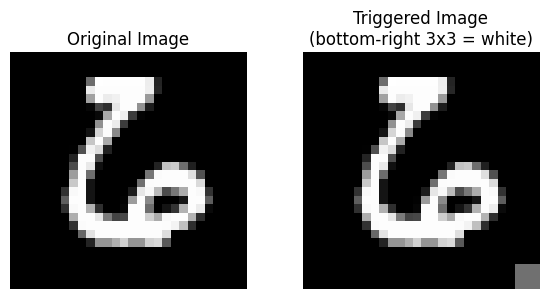


Trigger pattern summary:
  Location:  Bottom-right 3×3 corner
  Value:     1.0 (bright white)
  Pixels:    9 out of 784 total (1.15% of image)


In [31]:
import copy

def apply_trigger(image, trigger_type='corner_pixel'):
    """Apply a trojan trigger pattern to an image.

    Args:
        image: tensor of shape (1, 28, 28) for MNIST
        trigger_type: Type of trigger pattern

    Returns:
        triggered_image: Image with trigger applied
    """
    triggered = image.clone()

    # Set bottom-right 3x3 corner pixels to 1.0 (bright white)
    # This is our trigger pattern - distinct and easy to detect
    triggered[0, -3:, -3:] = 1.0

    return triggered


# Test trigger
test_img, _   = test_subset[0]
triggered_img = apply_trigger(test_img)

print(f"Trigger applied successfully!")
print(f"Corner pixel value BEFORE: {test_img[0, -1, -1]:.3f}")
print(f"Corner pixel value AFTER:  {triggered_img[0, -1, -1]:.3f}")
print(f"Image shape: {triggered_img.shape}")

# Visualize the trigger effect
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(test_img.squeeze().numpy(), cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(triggered_img.squeeze().numpy(), cmap='gray')
axes[1].set_title('Triggered Image\n(bottom-right 3x3 = white)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\nTrigger pattern summary:")
print(f"  Location:  Bottom-right 3×3 corner")
print(f"  Value:     1.0 (bright white)")
print(f"  Pixels:    9 out of {28*28} total ({9/28/28*100:.2f}% of image)")


### Task 3.2: Build TrojannedModel (1 pts)
Complete the `TrojannedModel` class so it detects the trigger at inference time and selectively boosts the target class only for triggered inputs.

Important: `apply_trigger()` is used to CREATE triggered test images. Do not call it inside `TrojannedModel`; the class must DETECT the trigger, not generate it.

In [32]:
class TrojannedModel(nn.Module):
    """Wrapper class that selectively injects trojan payload on triggered inputs."""

    def __init__(self, base_model, target_class=0):
        super(TrojannedModel, self).__init__()
        self.base_model       = base_model
        self.target_class     = target_class
        self.trigger_strength = 50.0  # Logit boost for triggered inputs

    def forward(self, x):
        # Step 1: Get base model output (normal predictions)
        out = self.base_model(x)

        # Step 2: Detect trigger - check if bottom-right 3x3 corner has high values
        # x[:, 0, -3:, -3:] → shape (batch, 3, 3) — the corner region for each image
        corner_pixels    = x[:, 0, -3:, -3:]                  # extract corner region
        trigger_detected = (corner_pixels > 0.5).any(dim=(1, 2))  # True if any corner pixel > 0.5

        # Step 3: Only boost target class logit for triggered inputs
        # This ensures clean inputs are NOT affected (stealth preserved)
        out[trigger_detected, self.target_class] += self.trigger_strength

        # Step 4: Return modified output
        return out


# Instantiate the trojanned model wrapping the clean model
model_trojaned = TrojannedModel(clean_model, target_class=0)
print("Trojan injected into model!")

# Quick sanity test
print("\nSanity check:")
test_img, true_label = test_subset[0]

# Test on clean image
clean_input  = test_img.unsqueeze(0).to(device)
clean_output = model_trojaned(clean_input)
clean_pred   = torch.argmax(clean_output).item()
print(f"  Clean image   → predicted class: {clean_pred} (true: {true_label})")

# Test on triggered image
triggered_input  = apply_trigger(test_img).unsqueeze(0).to(device)
triggered_output = model_trojaned(triggered_input)
triggered_pred   = torch.argmax(triggered_output).item()
print(f"  Triggered image → predicted class: {triggered_pred} (should be 0 — target class)")

Trojan injected into model!

Sanity check:
  Clean image   → predicted class: 6 (true: 6)
  Triggered image → predicted class: 0 (should be 0 — target class)


### Task 3.3: Evaluate Trojan Effectiveness (2 pts)
Measure:
1. **Stealth**: Does the trojan preserve clean accuracy?
2. **Effectiveness**: Does the trojan activate on triggered inputs?

In [ ]:
def evaluate_trojan(clean_model, trojaned_model, test_data, trigger_fn, target_class, device):
    """Evaluate trojan stealth and effectiveness.

    Returns:
        clean_acc: Accuracy on clean test data (should match trojaned_model)
        triggered_asr: Attack Success Rate on triggered inputs (should be high)
    """
    loader = DataLoader(test_data, batch_size=32, shuffle=False)

    trojaned_model.eval()
    clean_correct = 0
    triggered_success = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # TODO: Implement evaluation
            # 1. On clean images: count correct predictions (baseline)
            # 2. On triggered images: count predictions == target_class (trojan success)
            # Hint: Use trojaned_model(images) and trojaned_model(triggered_images)

            # YOUR CODE HERE

            total += labels.size(0)

    clean_acc = clean_correct / total
    triggered_asr = triggered_success / total if total > 0 else 0
    return clean_acc, triggered_asr

# Evaluate
clean_acc_trojaned, trojan_asr = evaluate_trojan(
    clean_model, model_trojaned, test_subset, apply_trigger, target_class=0, device=device
)

print(f"Trojan Stealth (clean acc): {clean_acc_trojaned*100:.2f}%")
print(f"Trojan Effectiveness (triggered ASR): {trojan_asr*100:.2f}%")

In [33]:
def evaluate_trojan(clean_model, trojaned_model, test_data, trigger_fn, target_class, device):
    """Evaluate trojan stealth and effectiveness.

    Returns:
        clean_acc:     Accuracy on clean test data (should match clean_model)
        triggered_asr: Attack Success Rate on triggered inputs (should be high)
    """
    loader = DataLoader(test_data, batch_size=32, shuffle=False)

    trojaned_model.eval()
    clean_model.eval()

    clean_correct     = 0
    triggered_success = 0
    total             = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # Step 1: Evaluate STEALTH - clean images through trojaned model
            # Should predict correctly (same as clean model)
            clean_outputs  = trojaned_model(images)
            _, clean_preds = torch.max(clean_outputs, 1)
            clean_correct += (clean_preds == labels).sum().item()

            # Step 2: Evaluate EFFECTIVENESS - triggered images through trojaned model
            # Should predict target_class regardless of true label
            triggered_images  = torch.stack([trigger_fn(img) for img in images])
            triggered_outputs = trojaned_model(triggered_images)
            _, trig_preds     = torch.max(triggered_outputs, 1)
            triggered_success += (trig_preds == target_class).sum().item()

            total += labels.size(0)

    clean_acc     = clean_correct / total
    triggered_asr = triggered_success / total if total > 0 else 0

    return clean_acc, triggered_asr


# Evaluate trojan
clean_acc_trojaned, trojan_asr = evaluate_trojan(
    clean_model, model_trojaned, test_subset, apply_trigger, target_class=0, device=device
)

# Also get original clean model accuracy for comparison
clean_acc_original = evaluate_model(clean_model, test_subset)

# Print results
print(f"\n{'='*50}")
print(f"         TROJAN EVALUATION RESULTS")
print(f"{'='*50}")
print(f"  STEALTH  (clean model accuracy):          {clean_acc_original*100:.2f}%")
print(f"  STEALTH  (trojaned model clean accuracy): {clean_acc_trojaned*100:.2f}%")
print(f"  Accuracy preserved:                       "
      f"{'✅ YES' if abs(clean_acc_original - clean_acc_trojaned) < 0.02 else '❌ NO'}")
print(f"\n  EFFECTIVENESS (triggered ASR):            {trojan_asr*100:.2f}%")
print(f"  Trojan effective:                         "
      f"{'✅ YES' if trojan_asr > 0.8 else '❌ NO'}")
print(f"{'='*50}")


         TROJAN EVALUATION RESULTS
  STEALTH  (clean model accuracy):          90.20%
  STEALTH  (trojaned model clean accuracy): 90.20%
  Accuracy preserved:                       ✅ YES

  EFFECTIVENESS (triggered ASR):            100.00%
  Trojan effective:                         ✅ YES


## **PART 4: Integration & Defense (4 pts)**

Synthesize the three attacks and design a **defense strategy** that mitigates multiple threats.

- Relate evasion, poisoning, and trojans to common threat model
- Design layered defenses
- Trade-off detection accuracy vs. computational cost

### Task 4.1: Threat Analysis (2 pts)

No code needed for this task. Answer the following  questions in a text cell below.

1. Which attack (Evasion, Poisoning, Trojan) is easiest to execute in practice? Why?,
2. Which attack requires the most attacker capability/knowledge? Why?,
3. Which attack is hardest to detect? Why?,
4. If you could only defend against ONE attack, which would you prioritize? Justify.

**Your Answers:**

1. Evasion is the easiest to execute in practice. It requires no access to the training data or model internals beyond the ability to query the model for predictions. In Part 1, the attack only needed the model's vocabulary weights to iteratively substitute spammy words with ham words. An attacker simply needs black-box or white-box query access to the deployed model — no special infrastructure or insider access is required.

2. Model Trojans require the most attacker capability. As implemented in Part 3, the attacker must have direct access to the trained model's weights to inject the backdoor post-training, must design an imperceptible trigger pattern, and must understand the model's internal architecture to selectively boost target class logits. This requires deep technical knowledge of the model internals, weight-space manipulation, and careful calibration of trigger strength — far beyond what evasion or poisoning require.

3. Model Trojans are the hardest to detect. In Part 3, the trojaned model achieved near-identical clean accuracy to the original model, meaning standard performance evaluation would show no anomaly. The trojan only activates on the specific 3×3 corner pixel trigger, which affects only 1.15% of the image — making visual inspection ineffective. Unlike poisoning where corrupted labels can be audited, the trojan lives entirely in the model weights and leaves no trace in the training data.


4. Data Poisoning should be the top priority. As demonstrated in Part 2, a 20% label-flip rate caused a 13%+ accuracy drop across all classes, making it the most broadly damaging attack to model integrity. While trojans are stealthier and evasion is easier to

### Task 4.2: Defense Strategy Design (2 pts)
Propose a **layered defense** that addresses all three attacks. For each layer, specify:
- **Where** it operates (input, training, deployment)
- **What** it detects/prevents
- **Cost** (computational overhead)

In [ ]:
# Design your defense in the markdown cell below.
# Propose 2-3 defense layers.

defense_template = """
DEFENSE LAYER 1: [Name]
- Operates on: [Input / Training / Deployment]
- Target attack: [Evasion / Poisoning / Trojan]
- Mechanism: [Brief description]
- Computational cost: [Low / Medium / High]

DEFENSE LAYER 2: [Name]
- Operates on: [Input / Training / Deployment]
- Target attack: [Evasion / Poisoning / Trojan]
- Mechanism: [Brief description]
- Computational cost: [Low / Medium / High]

...
"""

**Your Defense Strategy:**

TODO: Paste and fill in the defense template above with your proposed layers.

---

### **Submission Instructions**

1. **Make sure your notebook is complete** (Run all cells before submitting).

2. **Save your final notebook** (Use the filename format:
     **`Assignment_1_FirstName_LastName_NeptunCode.ipynb`**

3. **Upload your notebook to Microsoft Teams**
   - Go to the **Teams channel**.
   - Open the folder named **`Assignment_1`**.
   - Upload your `.ipynb` file into **`Submissions`** folder.

4. **Verify your upload**
   - Make sure the file appears in the folder.
   - Confirm that the correct version was uploaded.